In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import cumulative_trapezoid, trapezoid
import math
import os
import time
import random
import pickle as pkl
from cratersfd import *
%matplotlib inline
mpl.rcParams['font.family'] = 'Helvetica'

In [2]:
ctx_ds = np.loadtxt('../data/DIAMS_CTX.txt')
hirise_ds = np.loadtxt('../data/DIAMS_HiRISE.txt')

ctx_area = 297.73
ctx_d_max = 3.
hirise_area = 101.90
hirise_d_max = 3.

hirise_ds = hirise_ds[hirise_ds > 0.007]

<Figure size 640x480 with 0 Axes>

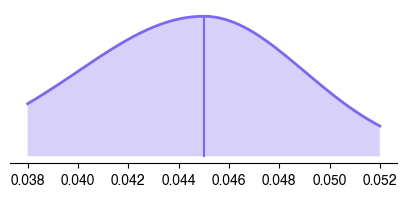

<Figure size 640x480 with 0 Axes>

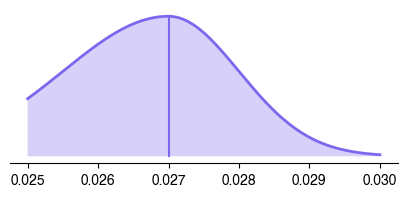

In [3]:
ctx_dmin = 0.045
ctx_dmin_min = 0.038
ctx_dmin_max = 0.052
ctx_dmin_rv = get_dmin_pdf(
    ctx_dmin, left_std=0.005, right_std=0.004,
    dmin_min=ctx_dmin_min, dmin_max=ctx_dmin_max
)

hirise_dmin = 0.027
hirise_dmin_min = 0.025
hirise_dmin_max = 0.030
hirise_dmin_rv = get_dmin_pdf(
    hirise_dmin, left_std=0.0015, right_std=0.001,
    dmin_min=hirise_dmin_min, dmin_max=hirise_dmin_max
)

ctx_dmin_rv.plot()
plt.figure()
hirise_dmin_rv.plot()

In [30]:
xlim=[0.0075, 0.15]
ylim=[9E-5, 1.3E-3]

letter_n = ord('a')
def letter(dy=0):
    global letter_n
    plt.text(
        0.015, 0.985 + dy, chr(letter_n), 
        transform=plt.gca().transAxes, 
        ha='left', va='top', size=15
    )
    letter_n += 1

def sfd_plots_fig():
    X, R = plot_sash_R(
        ctx_ds, ctx_area, color='blue'
    )
    ctx_sfd = fit_pf(X, R)
    plt.plot(
        ctx_dmin, ctx_sfd(ctx_dmin), 
        ls='', color='blue', marker='|', ms=10
    )
    bounds = (X > ctx_dmin_min) & (X < ctx_dmin_max)
    plt.plot(
        X[bounds], R[bounds], 
        alpha=0.2, lw=5, color='blue'
    )
    X, R = plot_sash_R(
        hirise_ds, hirise_area, color='red'
    )
    hirise_sfd = fit_pf(X, R)
    plt.plot(
        hirise_dmin, hirise_sfd(hirise_dmin), 
        ls='', color='red', marker='|', ms=10
    )
    bounds = (X > hirise_dmin_min) & (X < hirise_dmin_max)
    plt.plot(
        X[bounds], R[bounds], 
        alpha=0.2, lw=5, color='red'
    )
    plt.xlim(xlim)
    plt.ylim(ylim)
    plot_pf_isochrons(npf_mars_R)
    labels = [
        'CTX data', rf'CTX $D_{{min}}$ estimate', 
        rf'CTX $D_{{min}}$ PDF range',
        'HiRISE data', rf'HiRISE $D_{{min}}$ estimate', 
        rf'HiRISE $D_{{min}}$ PDF range', 
        'Martian NPF (Ivanov, 2001)'
    ]
    plt.legend(
        labels, fontsize=6, labelspacing=0.2,
        loc='lower left'
    )
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.xaxis.labelpad = 3
    letter()

def synth_plots_fig_ctx():
    X, R = plot_sash_R(
        ctx_ds, ctx_area, color='blue',
        show_craters=True, lw=0.8, crater_ms=8
    )
    ctx_sfd = fit_pf(X, R)
    merged_pf = merge_pfs_at(
        ctx_sfd, npf_mars_R, ctx_dmin
    )
    base = 'saved/ctx_synth.' + str(n_steps)
    X_saved = os.path.exists(base + '.X.csv')
    Ys_saved = os.path.exists(base + '.Ys.csv')
    load_saved = X_saved and Ys_saved
    time0()
    if load_saved:
        X = np.loadtxt(base + '.X.csv', delimiter=',')
        Ys = np.loadtxt(base + '.Ys.csv', delimiter=',')
        plot_sash_synth(
            ctx_ds, ctx_area, color='blue', plot_type='R',
            n_steps=n_steps, R_pf=merged_pf,
            X=X, synth_mean_Ys=Ys
        )
    else:
        X, Ys = plot_sash_synth(
            ctx_ds, ctx_area, color='blue', 
            plot_type='R', n_steps=n_steps, R_pf=merged_pf
        )
        np.savetxt(base + '.X.csv', X, delimiter=',')
        np.savetxt(base + '.Ys.csv', Ys, delimiter=',')
    runtime('Synthetic modeling time')
    plt.xlim(xlim)
    plt.ylim(ylim)
    labels = [
        'CTX crater diameters', 'CTX SASH model SFD',
        'Synthetic model error envelope',
        'SFD for synthetic model'
    ]
    plt.legend(
        labels, fontsize=6, labelspacing=0.2, loc='lower left'
    )
    letter()

def synth_plots_fig_hirise():
    X, R = plot_sash_R(
        hirise_ds, hirise_area, color='red',
        show_craters=True, lw=0.8, crater_ms=8
    )
    hirise_sfd = fit_pf(X, R)
    merged_pf = merge_pfs_at(
        hirise_sfd, npf_mars_R, hirise_dmin
    )
    base = 'saved/hirise_synth.' + str(n_steps)
    X_saved = os.path.exists(base + '.X.csv')
    Ys_saved = os.path.exists(base + '.Ys.csv')
    load_saved = X_saved and Ys_saved
    time0()
    if load_saved:
        X = np.loadtxt(base + '.X.csv', delimiter=',')
        Ys = np.loadtxt(base + '.Ys.csv', delimiter=',')
        plot_sash_synth(
            hirise_ds, hirise_area, color='red', plot_type='R',
            n_steps=n_steps, R_pf=merged_pf,
            X=X, synth_mean_Ys=Ys
        )
    else:
        X, Ys = plot_sash_synth(
            hirise_ds, hirise_area, color='red', 
            plot_type='R', n_steps=n_steps, R_pf=merged_pf
        )
        np.savetxt(base + '.X.csv', X, delimiter=',')
        np.savetxt(base + '.Ys.csv', Ys, delimiter=',')
    runtime('Synthetic modeling time')
    plt.xlim(xlim)
    plt.ylim(ylim)
    labels = [
        'HiRISE crater diameters', 'HiRISE SASH model SFD',
        'Synthetic model error envelope',
        'SFD for synthetic model'
    ]
    plt.legend(
        labels, fontsize=6, labelspacing=0.2, loc='lower left'
    )
    letter()

def age_comparison_fig():
    xlim = [0.0015, 0.011]
    age_pdf(
        ctx_ds, ctx_area, ctx_dmin, 
        systematic=1.0, additional=1.0, random=1.0,
        d_random=1.0, d_systematic=1.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    ).plot(
        label=True, xlim=xlim, color='blue', 
        pdf_label='CTX\nonly counting error',
        label_text_size=8
    )
    upshift = -1.1
    age_pdf(
        hirise_ds, hirise_area, hirise_dmin, 
        systematic=1.0, additional=1.0, random=1.0,
        d_random=1.0, d_systematic=1.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    ).plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='red', 
        pdf_label='HiRISE\nonly counting error',
        label_text_size=8
    )
    upshift -= 1.1
    age_pdf(
        ctx_ds, ctx_area, ctx_dmin_rv, 
        systematic=1.0, additional=1.05, random=1.8,
        d_random=1.05, d_systematic=1.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    ).plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='blue',
        pdf_label='CTX\nother error sources',
        label_text_size=8
    )
    upshift -= 1.1
    age_pdf(
        hirise_ds, hirise_area, hirise_dmin_rv, 
        systematic=1.0, additional=1.05, random=1.8,
        d_random=1.05, d_systematic=1.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    ).plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='red',
        pdf_label='HiRISE\nother error sources',
        label_text_size=8
    )
    plt.yticks([])
    plt.xlabel('Age (Ga)')
    letter(dy=0.015 / 3)

def age_fig():
    xlim = [1E-5, 0.0125]
    upshift = 0
    ctx_age_rv = age_pdf(
        ctx_ds, ctx_area, ctx_dmin_rv, 
        systematic=1.15, additional=1.1, random=1.8,
        d_random=1.05, d_systematic=1.01,
        pf=npf_mars, cf_inv=ncf_mars_inv
    )
    ctx_age_rv.plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='blue',
        pdf_label='Median CTX Age PDF\nwithout chronology error',
        label_text_size=8, pdf_gap_shift=0.1, label_shift_y=0.05
    )
    upshift -= 1.1
    hirise_age_rv = age_pdf(
        hirise_ds, hirise_area, hirise_dmin_rv, 
        systematic=1.15, additional=1.1, random=1.8,
        d_random=1.05, d_systematic=1.01,
        pf=npf_mars, cf_inv=ncf_mars_inv
    )
    hirise_age_rv.plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='red',
        pdf_label='Median HiRISE Age PDF\nwithout chronology error',
        label_text_size=8, pdf_gap_shift=0.1
    )
    upshift -= 1.1
    ctx_age_rv_cf = age_pdf(
        ctx_ds, ctx_area, ctx_dmin_rv, 
        systematic=1.15, additional=1.1, random=1.8,
        d_random=1.05, d_systematic=1.01, cf_error=3.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    )
    ctx_age_rv_cf.plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='blue',
        pdf_label='Median CTX Age PDF\nall error sources',
        label_text_size=8, pdf_gap_shift=0.1
    )
    upshift -= 1.1
    hirise_age_rv_cf = age_pdf(
        hirise_ds, hirise_area, hirise_dmin_rv, 
        systematic=1.15, additional=1.1, random=1.8,
        d_random=1.05, d_systematic=1.01, cf_error=3.0,
        pf=npf_mars, cf_inv=ncf_mars_inv
    )
    hirise_age_rv_cf.plot(
        label=True, upshift=upshift, 
        xlim=xlim, color='red',
        pdf_label='Median HiRISE Age PDF\nall error sources',
        label_text_size=8, pdf_gap_shift=0.1
    )
    upshift -= 1.1
    ctx_age_rv.plot(
        label=True, upshift=upshift, kind='mean', 
        xlim=xlim, color='blue',
        pdf_label='Mean CTX Age PDF\nwithout chronology error',
        label_text_size=8, pdf_gap_shift=0.1, label_shift_y=0.05
    )
    upshift -= 1.1
    ctx_age_rv_cf.plot(
        label=True, upshift=upshift, kind='mean', 
        xlim=xlim, color='blue',
        pdf_label='Mean CTX Age PDF\nall error sources',
        label_text_size=8, pdf_gap_shift=0.1
    )
    upshift -= 1.1
    hirise_age_rv.plot(
        label=True, upshift=upshift, kind='mean', 
        xlim=xlim, color='red',
        pdf_label='Mean HiRISE Age PDF\nwithout chronology error',
        label_text_size=8, pdf_gap_shift=0.1
    )
    upshift -= 1.1
    hirise_age_rv_cf.plot(
        label=True, upshift=upshift, kind='mean', 
        xlim=xlim, color='red',
        pdf_label='Mean HiRISE Age PDF\nall error sources',
        label_text_size=8, pdf_gap_shift=0.1
    )
    plt.yticks([])
    plt.xlabel('Age (Ga)')
    plt.ylim([-1.1 * 7 - 0.1, 1.1])
    letter(dy=0.015 * 2 / 3)

def dmin_pdf_fig():
    ctx_dmin_rv.plot(
        color='blue', xlim=[0.023, 0.052], 
        label=True, pdf_label=rf'CTX $D_{{min}}$ PDF'
    )
    hirise_dmin_rv.plot(
        color='red', upshift=-1.1,
        label=True, pdf_label=rf'HiRISE $D_{{min}}$ PDF'
    )
    ax = plt.gca()
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xlabel(rf'$D_{{min}}$ (km)')
    plt.yticks([])
    letter()

Calculation time: 0.00079 seconds
Calculation time: 0.00029 seconds
Calculation time: 0.00012 seconds
Synthetic modeling time: 2.09898 seconds
Calculation time: 0.00022 seconds
Synthetic modeling time: 2.06466 seconds


/Users/sam/Library/Python/3.12/lib/python/site-packages/numpy/lib/function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/sam/Library/Python/3.12/lib/python/site-packages/numpy/lib/function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/sam/Library/Python/3.12/lib/python/site-packages/numpy/lib/function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/sam/Library/Python/3.12/lib/python/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in multiply
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/Users/sam/Library/Python/3.12/lib/python/site-packages/numpy/lib/function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]
/Users/sam/Libra

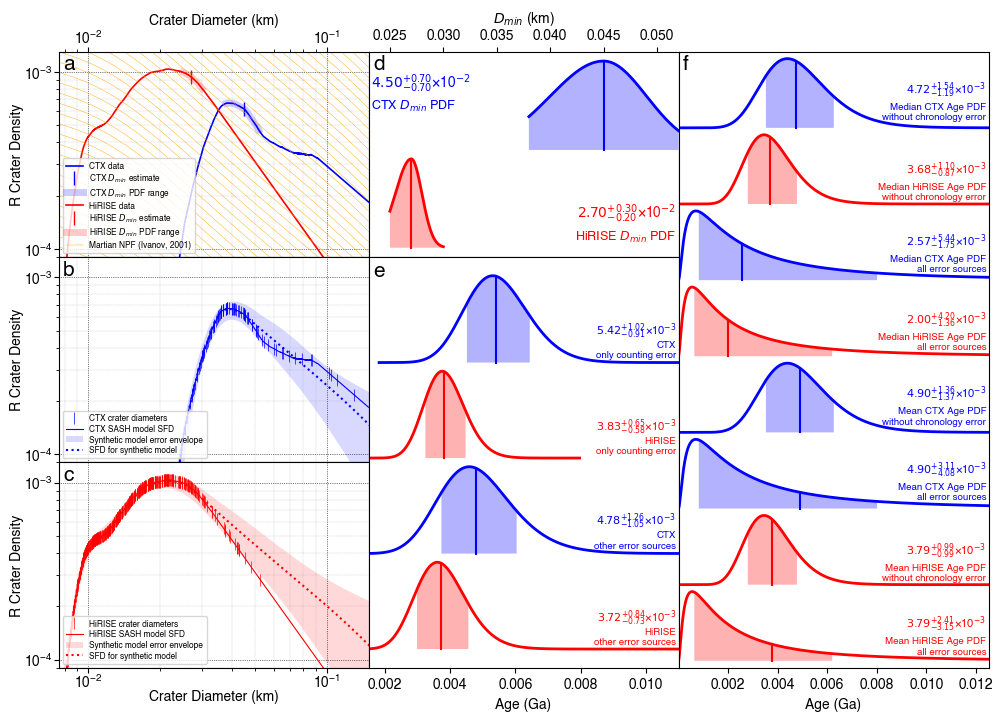

In [31]:
n_steps = 1000

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

plt.subplot(gs[0, 0])
sfd_plots_fig()

plt.subplot(gs[1, 0])
synth_plots_fig_ctx()

plt.subplot(gs[2, 0])
synth_plots_fig_hirise()

plt.subplot(gs[0, 1])
dmin_pdf_fig()

plt.subplot(gs[1:, 1])
age_comparison_fig()

plt.subplot(gs[:, 2])
age_fig()

plt.subplots_adjust(hspace=0, wspace=0)

f = 'figs/canala_comparison_' + str(n_steps) + '.pdf'
plt.gcf().savefig(f, bbox_inches='tight')